In [1]:
import pandas as pd
import numpy as np

import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../dataset/processed/future_price_forecast.csv"
)

df.head()

,id,date,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,...,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price,property_age,growth_score,annual_growth_rate,price_after_1_year,price_after_3_years,price_after_5_years
0,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,42847,3,76,838000,25,73.60,0.06,888280.0,998071.41,1121433.03
1,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,4500,1,51,805000,97,41.48,0.05,845250.0,931888.13,1027406.66
2,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,4750,1,67,790000,75,47.98,0.05,829500.0,914523.75,1008262.43
3,6762813157,42491,5,3.25,3660,11995,2.0,0,2,3,...,11241,3,72,785000,20,78.26,0.06,832100.0,934947.56,1050507.08
4,6762813599,42491,3,1.75,2240,10578,2.0,0,0,5,...,10578,3,71,750000,103,52.05,0.05,787500.0,868218.75,957211.17


In [3]:
model = joblib.load(
    "../models/best_house_price_model.pkl"
)

model

,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [4]:
features = [

    "number_of_bedrooms",
    "number_of_bathrooms",
    "living_area",
    "lot_area",
    "number_of_floors",
    "waterfront_present",
    "number_of_views",
    "condition_of_the_house",
    "grade_of_the_house",
    "house_area_without_basement",
    "area_of_the_basement",
    "built_year",
    "renovation_year",
    "postal_code",
    "lattitude",
    "longitude",
    "living_area_renov",
    "lot_area_renov",
    "number_of_schools_nearby",
    "distance_from_the_airport",
    "property_age"

]

df = df.rename(
    columns={
        "area_of_the_house(excluding_basement)":
        "house_area_without_basement"
    }
)

X = df[features]

X.head()

,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,house_area_without_basement,...,built_year,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,property_age
0,4,2.50,3310,42998,2.0,0,0,3,9,3310,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,25
1,3,2.00,2710,4500,1.5,0,0,4,8,1880,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,97
2,3,2.50,2600,4750,1.0,0,0,4,9,1700,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,75
3,5,3.25,3660,11995,2.0,0,2,3,10,3660,...,2006,0,122008,52.7637,-114.050,3320,11241,3,72,20
4,3,1.75,2240,10578,2.0,0,0,5,8,1550,...,1923,0,122006,52.9254,-114.482,1570,10578,3,71,103


In [5]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

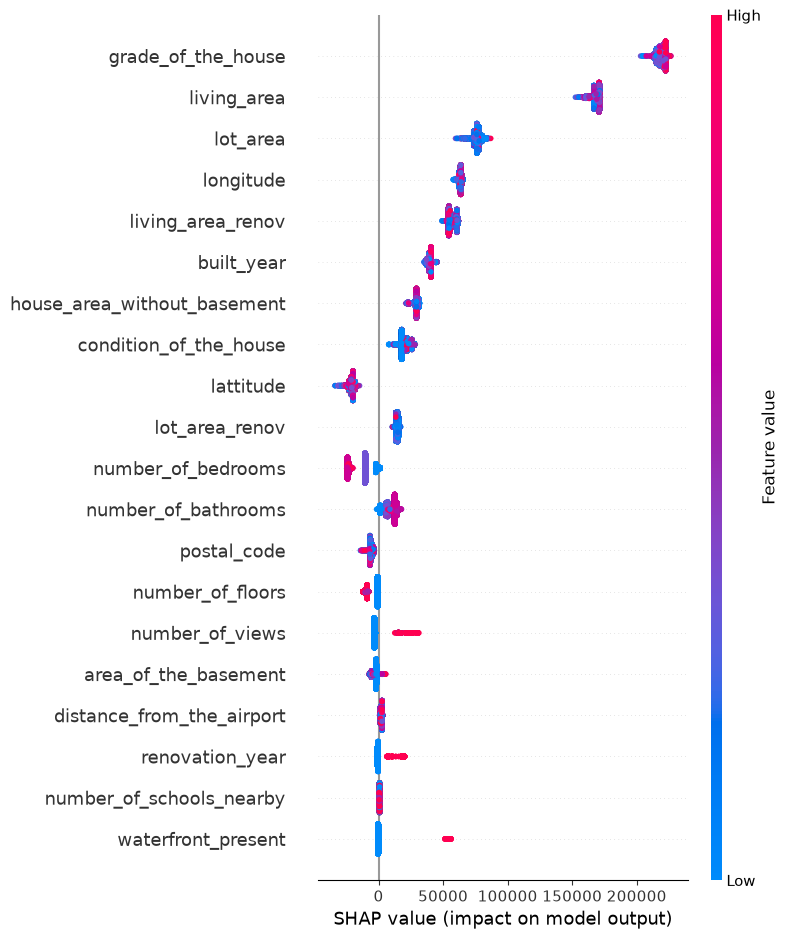

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../assets/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Save SHAP values

import joblib

joblib.dump(
    shap_values,
    "../models/shap_values.pkl"
)

print("SHAP values saved successfully!")

SHAP values saved successfully!


In [8]:
import joblib

joblib.dump(X, "../models/shap_features.pkl")

print("Feature matrix saved successfully!")

Feature matrix saved successfully!
